# Scania APS - Preprocessing, and what this dataset does not need

The tabular module's raw data is 60,000 truck service records over 170 anonymised
counters, 1.67 per cent of them air-pressure failures, with 8.3 per cent of all
cells missing. The obvious response is the standard imbalanced-classification
recipe: drop the columns that are mostly empty, impute the rest, scale everything
to a common range, and resample until the classes are even.

**The shipped model does none of that, and this notebook is where each of those
four decisions is measured rather than assumed.** Every one of them is prepared
here, so notebook 03 can score it on the test set instead of arguing about it:

1. **Drop the mostly-missing columns?** Measured against how differently they go
   missing in the two classes.
2. **Impute?** Fitted on the training rows, kept as one of the four candidates
   notebook 03 selects between.
3. **Scale?** Measured on two fits of the same model, one scaled and one not.
4. **Resample?** SMOTE is built here in full, because notebook 03 measures what
   the whole textbook pipeline costs against the shipped one.

The last question is the one that decides the module: **what a decision threshold
can be**. The shipped threshold is 0.0024, and an earlier version of this notebook
pair searched a grid that started at 0.10. Section 10 puts both on the same axis.

**Nothing here is imported from `scania_aps.py`.** The loading, the label, the
cost metric and the threshold search are written out again, and section 11
compares the result against the artifact the deployed model left behind.

## 1. Imports and configuration

In [1]:
import sys
from pathlib import Path

# Add notebooks/utils to path (works on Mac, Windows, Linux)
_nb_root = Path('..').resolve()
if str(_nb_root) not in sys.path:
    sys.path.insert(0, str(_nb_root))

from utils.arkon_utils import save_figure

print('arkon_utils loaded')

arkon_utils loaded


In [2]:
import imblearn
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import MinMaxScaler
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

ASSETS = 'ml'

print(f'python   {sys.version.split()[0]}')
print(f'pandas   {pd.__version__}')
print(f'numpy    {np.__version__}')
print(f'xgboost  {xgboost.__version__}')
print(f'imblearn {imblearn.__version__}')

python   3.12.10
pandas   2.3.3
numpy    2.4.4
xgboost  3.2.0
imblearn 0.14.1


## 2. Constants

The raw files are not plain CSV: each one opens with a 20-line licence header
before the column names, and missing values are the string `na` rather than an
empty field. Both are read wrongly by default and silently, which is why they are
constants here and not buried in a call.

The cost figures are the dataset's own, from `aps_failure_description.txt`. They
are the reason this module exists: 50 to 1 makes the decision threshold the main
lever, not a default to leave alone.

In [3]:
RAW_DIR = Path('../../data/02_scania/raw')
PROC_DIR = Path('../../data/02_scania/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

# The raw files carry a 20-line licence header before the CSV header row.
HEADER_LINES = 20
SEED = 42

# The challenge metric, from data/02_scania/raw/aps_failure_description.txt.
COST_FALSE_POSITIVE = 10   # an unnecessary check by a mechanic
COST_FALSE_NEGATIVE = 500  # a missed faulty truck, which may break down

# The threshold grid the earlier version of this notebook pair searched.
GRID = np.arange(0.10, 0.90, 0.01)

print(f'cost: {COST_FALSE_POSITIVE} per false positive, '
      f'{COST_FALSE_NEGATIVE} per false negative, ratio 1 to '
      f'{COST_FALSE_NEGATIVE // COST_FALSE_POSITIVE}')
print(f'grid searched by the earlier notebook: {GRID[0]:.2f} to {GRID[-1]:.2f} '
      f'in {len(GRID)} steps')
# The relative path, not the resolved one: this repository is public and a
# stored cell output is not the place for the author's drive layout.
print(f'raw : {RAW_DIR} (exists: {RAW_DIR.exists()})')
print(f'out : {PROC_DIR} (exists: {PROC_DIR.exists()})')

cost: 10 per false positive, 500 per false negative, ratio 1 to 50
grid searched by the earlier notebook: 0.10 to 0.89 in 80 steps
raw : ..\..\data\02_scania\raw (exists: True)
out : ..\..\data\02_scania\processed (exists: True)


## 3. Load the fleet

Missing values stay missing. That is a decision, not an oversight, and section 6
is where it is argued: XGBoost sends a missing value down a learned default
branch at every split, so a column can contribute through the values it does have
and through the pattern of where it does not.

In [4]:
def load(name):
    """One raw file. Missing values stay NaN, the label becomes 0 or 1."""
    frame = pd.read_csv(RAW_DIR / name, skiprows=HEADER_LINES, na_values='na',
                        low_memory=False)
    y = (frame['class'] == 'pos').astype(int).to_numpy()
    X = frame.drop(columns=['class']).astype('float64')
    return X, y


X_train, y_train = load('aps_failure_training_set.csv')
X_test, y_test = load('aps_failure_test_set.csv')
features = list(X_train.columns)

print(f'train {X_train.shape}, test {X_test.shape}, {len(features)} features')
print(f'positives: train {y_train.sum()} ({100 * y_train.mean():.2f}%), '
      f'test {y_test.sum()} ({100 * y_test.mean():.2f}%)')
print(f'first five columns: {features[:5]}')

train (60000, 170), test (16000, 170), 170 features
positives: train 1000 (1.67%), test 375 (2.34%)
first five columns: ['aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000']


## 4. The imbalance, and what doing nothing costs

Accuracy is unusable here before a single model is trained. A classifier that
answers "no failure" to every record is right 98.3 per cent of the time on the
training split, and it costs half a million on the metric the business cares
about. That number is the floor every model in notebook 03 is measured against.

Note the second row: the test split is not drawn from the same prevalence as the
training split. 1.67 per cent against 2.34 per cent, supplied that way with the
dataset. A threshold tuned on one prevalence is being applied at another, which is
limitation 3 of the model card.

In [5]:
rows = []
for name, y in [('train', y_train), ('test', y_test)]:
    rows.append({'split': name, 'rows': len(y), 'positives': int(y.sum()),
                 'prevalence_%': round(100 * y.mean(), 2),
                 'accuracy_always_neg_%': round(100 * (1 - y.mean()), 2),
                 'cost_always_neg': int(COST_FALSE_NEGATIVE * y.sum())})
print(pd.DataFrame(rows).to_string(index=False))

split  rows  positives  prevalence_%  accuracy_always_neg_%  cost_always_neg
train 60000       1000          1.67                  98.33           500000
 test 16000        375          2.34                  97.66           187500


  ✓ Saved → assets\ml\scania_prep_class_balance.png


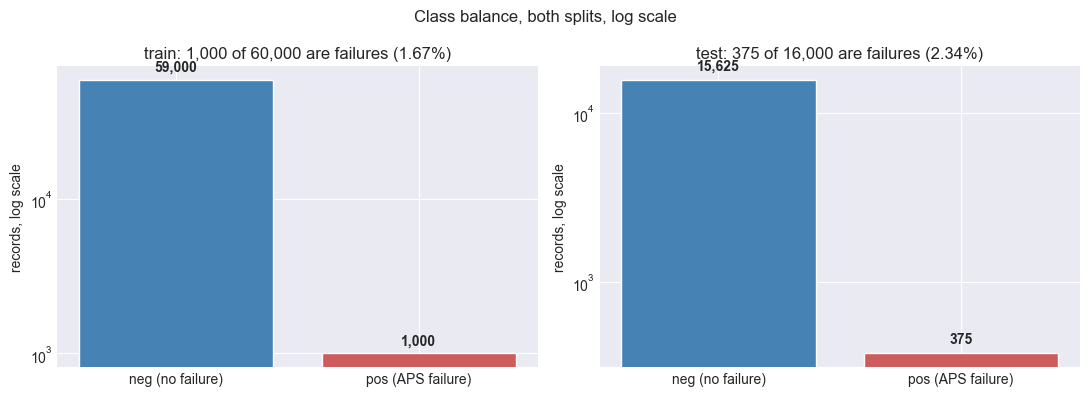

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, name, y in [(axes[0], 'train', y_train), (axes[1], 'test', y_test)]:
    counts = np.bincount(y)
    bars = ax.bar(['neg (no failure)', 'pos (APS failure)'], counts,
                  color=['steelblue', 'indianred'], edgecolor='white')
    ax.set_yscale('log')
    ax.set_ylabel('records, log scale')
    ax.set_title(f'{name}: {counts[1]:,} of {counts.sum():,} are failures '
                 f'({100 * counts[1] / counts.sum():.2f}%)')
    for bar, value in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, value * 1.15, f'{value:,}',
                ha='center', fontweight='bold')

plt.suptitle('Class balance, both splits, log scale')
plt.tight_layout()
save_figure(fig, 'scania_prep_class_balance', subfolder=ASSETS)
plt.show()

## 5. Where the missing values are

Not spread evenly, which is what makes the drop rule in section 6 a real question
rather than housekeeping.

In [7]:
missing_rate = X_train.isna().mean()
overall = float(X_train.isna().to_numpy().mean())
worst = missing_rate.sort_values(ascending=False)

print(f'missing cells overall  : {100 * overall:.1f}%')
print(f'columns with any missing: {(missing_rate > 0).sum()} of {len(features)}')
print(f'columns above 50%      : {(missing_rate > 0.5).sum()}')
print(f'columns above 90%      : {(missing_rate > 0.9).sum()}')
print('\nworst five columns, missing rate in per cent:')
print((100 * worst.head(5)).round(1).to_string())

missing cells overall  : 8.3%
columns with any missing: 169 of 170
columns above 50%      : 8
columns above 90%      : 0

worst five columns, missing rate in per cent:
br_000    82.1
bq_000    81.2
bp_000    79.6
bo_000    77.2
ab_000    77.2


  ✓ Saved → assets\ml\scania_prep_missing_values.png


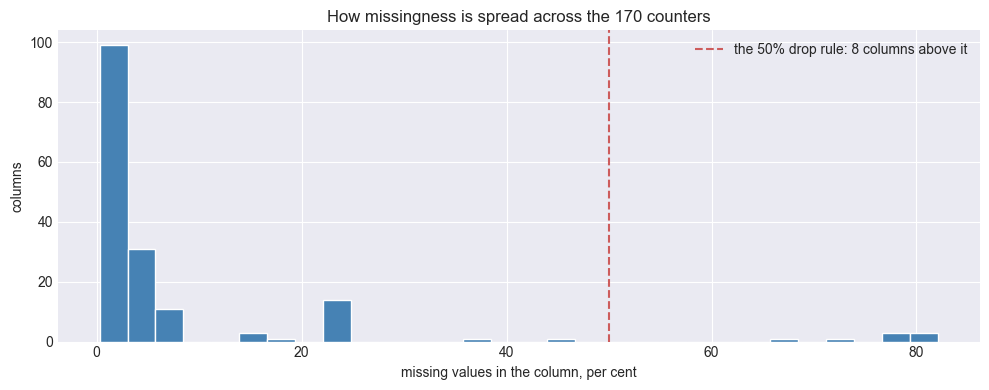

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(100 * missing_rate[missing_rate > 0], bins=30, color='steelblue',
        edgecolor='white')
ax.axvline(50, color='indianred', linestyle='--',
           label=f'the 50% drop rule: {(missing_rate > 0.5).sum()} columns above it')
ax.set_xlabel('missing values in the column, per cent')
ax.set_ylabel('columns')
ax.set_title('How missingness is spread across the 170 counters')
ax.legend()
plt.tight_layout()
save_figure(fig, 'scania_prep_missing_values', subfolder=ASSETS)
plt.show()

## 6. Decision 1: drop the columns that are mostly missing?

The rule is to drop any column missing in more than half the rows, on the grounds
that imputing it invents most of it. That reasoning is sound **if the column has
to be imputed**, and it is what forces the question: does it?

The measurement below is not how much is missing but **how differently it goes
missing in the two classes**. If a counter is absent for 8 per cent of healthy
trucks and 60 per cent of failing ones, then its absence is one of the strongest
signals in the file, and both dropping it and filling it with a median destroy
that signal in the same move.

In [9]:
drop_rule = missing_rate[missing_rate > 0.5].index.tolist()
print(f'the >50% rule would drop {len(drop_rule)} of {len(features)} columns: '
      f'{drop_rule}')

# Missingness by class: is being absent itself a signal?
by_class = pd.DataFrame({
    'missing_neg_%': 100 * X_train[y_train == 0].isna().mean(),
    'missing_pos_%': 100 * X_train[y_train == 1].isna().mean()})
by_class['gap'] = by_class['missing_pos_%'] - by_class['missing_neg_%']
ranked = by_class.reindex(by_class.gap.abs().sort_values(ascending=False).index)

print('\nlargest gaps between the classes in how often a column is missing:')
print(ranked.head(8).round(1).to_string())
print(f'\ncolumns where the gap exceeds 10 points: {(ranked.gap.abs() > 10).sum()}')
print(f'of those, caught by the >50% drop rule : '
      f'{len(set(ranked.index[ranked.gap.abs() > 10]) & set(drop_rule))}')

the >50% rule would drop 8 of 170 columns: ['ab_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cr_000']

largest gaps between the classes in how often a column is missing:
        missing_neg_%  missing_pos_%   gap
br_000           83.3            9.0 -74.3
bq_000           82.4            8.7 -73.7
bp_000           80.8            8.3 -72.5
bo_000           78.4            7.8 -70.6
bn_000           74.5            7.4 -67.1
bm_000           66.9            7.1 -59.8
ak_000            6.6           53.2  46.6
ca_000            6.5           53.0  46.5

columns where the gap exceeds 10 points: 64
of those, caught by the >50% drop rule : 6


## 7. Decision 2: median imputation

Fitted on the training rows only and applied to both splits, so no test statistic
reaches the model. It is kept as a **candidate**, not adopted: notebook 03 runs
the selection with it and without it, and the two arms come out inside the noise
of each other.

What the plot shows is why it is not free. The worst column is missing in four
rows out of five, and after imputation four rows out of five carry exactly the
same number, which is a value the truck never reported.

In [10]:
imputer = SimpleImputer(strategy='median').fit(X_train)
imputed_train = pd.DataFrame(imputer.transform(X_train), columns=features)
imputed_test = pd.DataFrame(imputer.transform(X_test), columns=features)

worst_col = worst.index[0]
median_value = imputer.statistics_[features.index(worst_col)]
print(f'worst column {worst_col}: missing in {100 * missing_rate[worst_col]:.1f}% '
      f'of training rows')
print(f'training median used to fill it: {median_value:,.1f}')
print(f'after imputation, share of rows sitting exactly on that median: '
      f'{100 * (imputed_train[worst_col] == median_value).mean():.1f}%')
print(f'missing cells remaining: {int(imputed_train.isna().to_numpy().sum())}')

worst column br_000: missing in 82.1% of training rows
training median used to fill it: 320,400.0
after imputation, share of rows sitting exactly on that median: 82.1%
missing cells remaining: 0


  ✓ Saved → assets\ml\scania_prep_imputation.png


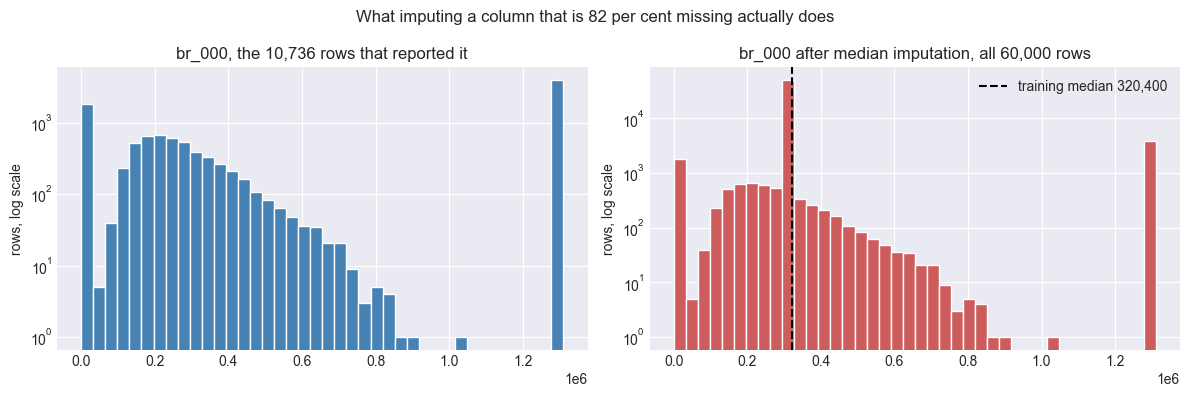

In [11]:
observed = X_train[worst_col].dropna()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
axes[0].hist(observed, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'{worst_col}, the {len(observed):,} rows that reported it')
axes[1].hist(imputed_train[worst_col], bins=40, color='indianred', edgecolor='white')
axes[1].axvline(median_value, color='black', linestyle='--',
                label=f'training median {median_value:,.0f}')
axes[1].set_title(f'{worst_col} after median imputation, all {len(imputed_train):,} rows')
axes[1].legend()
for ax in axes:
    ax.set_yscale('log')
    ax.set_ylabel('rows, log scale')
plt.suptitle('What imputing a column that is 82 per cent missing actually does')
plt.tight_layout()
save_figure(fig, 'scania_prep_imputation', subfolder=ASSETS)
plt.show()

## 8. Decision 3: scale the features?

A tree never compares two different columns to each other, it only asks whether
one column's value is above a split point. Rescale that column and the split point
moves with it, so the tree is unchanged. Standard advice to normalise before
training is inherited from models where distance or a gradient step actually sees
the units, and it does not transfer.

Asserted in one line, and measured in the next: the same model, the same seed and
the same rows, fitted once on imputed data and once on the same data squeezed into
[0, 1], then both scored on the test set.

In [12]:
scaler = MinMaxScaler().fit(imputed_train)
scaled_train = pd.DataFrame(scaler.transform(imputed_train), columns=features)
scaled_test = pd.DataFrame(scaler.transform(imputed_test), columns=features)

probe = dict(n_estimators=60, max_depth=4, learning_rate=0.1, random_state=SEED,
             n_jobs=-1, tree_method='hist', eval_metric='aucpr')
unscaled_scores = XGBClassifier(**probe).fit(
    imputed_train, y_train).predict_proba(imputed_test)[:, 1]
scaled_scores = XGBClassifier(**probe).fit(
    scaled_train, y_train).predict_proba(scaled_test)[:, 1]

print(f'largest difference between the two score vectors: '
      f'{np.abs(unscaled_scores - scaled_scores).max():.3e}')
print(f'rows ranked differently by the two models: '
      f'{int((np.argsort(-unscaled_scores) != np.argsort(-scaled_scores)).sum())} '
      f'of {len(y_test):,}')

largest difference between the two score vectors: 0.000e+00
rows ranked differently by the two models: 0 of 16,000


## 9. Decision 4: SMOTE

SMOTE invents minority rows by interpolating between a failure and its nearest
failing neighbours. It cannot run on missing values and it measures distance
across columns, so **it is the step that forces the other two**: imputation to
remove the gaps, and scaling so that a counter running to 10^8 does not decide
every neighbourhood on its own. That dependency is the reason the earlier version
of this notebook did all three, and it is worth seeing as a chain rather than as
three independent good ideas.

It is built here in full and handed to notebook 03, which scores the whole
textbook pipeline against the shipped one on the test set.

The consequence to carry into the next notebook: after SMOTE the model is trained
on a 50 per cent failure rate instead of 1.67 per cent, so its scores come out on
a different scale and its cost-optimal threshold is not the shipped one. Whether
that shift is large enough to bring the operating point inside the 0.10 to 0.89
grid is a question with a number attached, and notebook 03 section 10 measures it
rather than assuming it either way.

In [13]:
balanced_X, balanced_y = SMOTE(random_state=SEED).fit_resample(scaled_train, y_train)

before, after = np.bincount(y_train), np.bincount(balanced_y)
print(f'before SMOTE: {before.tolist()}, positives {100 * before[1] / before.sum():.2f}%')
print(f'after  SMOTE: {after.tolist()}, positives {100 * after[1] / after.sum():.2f}%')
print(f'synthetic rows added: {len(balanced_y) - len(y_train):,}')
print(f'training matrix grows from {X_train.shape} to {balanced_X.shape}')

before SMOTE: [59000, 1000], positives 1.67%
after  SMOTE: [59000, 59000], positives 50.00%
synthetic rows added: 58,000
training matrix grows from (60000, 170) to (118000, 170)


  ✓ Saved → assets\ml\scania_prep_smote.png


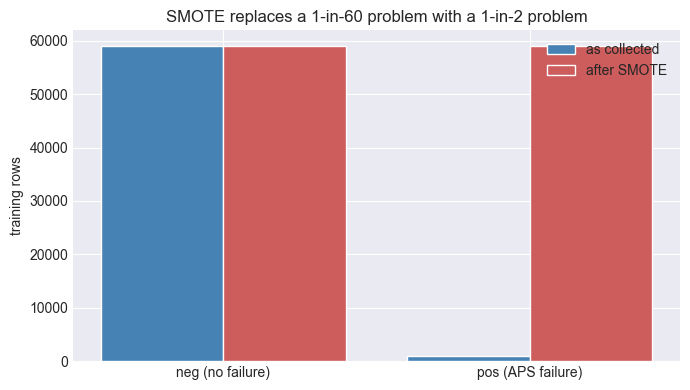

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
index = np.arange(2)
ax.bar(index - 0.2, before, width=0.4, color='steelblue', edgecolor='white',
       label='as collected')
ax.bar(index + 0.2, after, width=0.4, color='indianred', edgecolor='white',
       label='after SMOTE')
ax.set_xticks(index)
ax.set_xticklabels(['neg (no failure)', 'pos (APS failure)'])
ax.set_ylabel('training rows')
ax.set_title('SMOTE replaces a 1-in-60 problem with a 1-in-2 problem')
ax.legend()
plt.tight_layout()
save_figure(fig, 'scania_prep_smote', subfolder=ASSETS)
plt.show()

## 10. The cost metric, and what a threshold grid can represent

The search below is exact rather than a grid. Sorting the scores once makes every
distinct score a candidate boundary, and the cost at each is a running count, so
the true minimum is found in one pass instead of being stepped over.

The demonstration uses one held-out fifth of the training rows, scored by a model
that never saw them. It is not the selection - notebook 03 does that properly,
over five folds and three seeds - it is here to put the exact optimum and the
grid floor of 0.10 on the same axis.

In [15]:
def scania_cost(y_true, y_pred):
    """The challenge metric: 10 per needless check, 500 per missed truck."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return int(COST_FALSE_POSITIVE * fp + COST_FALSE_NEGATIVE * fn)


def best_threshold(y_true, scores):
    """The probability cut that minimises cost on these scores.

    Every distinct score is a candidate boundary, so the search is exact. A fixed
    grid can step over the optimum when the scores cluster, which they do here
    because most trucks are obviously healthy.
    """
    order = np.argsort(-scores)
    labels = y_true[order]
    positives = int(labels.sum())
    true_positives = np.concatenate([[0], np.cumsum(labels)])
    predicted = np.arange(len(labels) + 1)
    false_positives = predicted - true_positives
    false_negatives = positives - true_positives
    costs = (COST_FALSE_POSITIVE * false_positives
             + COST_FALSE_NEGATIVE * false_negatives)
    k = int(np.argmin(costs))
    sorted_scores = scores[order]
    if k == 0:
        cut = float(sorted_scores[0]) + 1e-9
    elif k >= len(sorted_scores):
        cut = float(sorted_scores[-1])
    else:
        cut = float((sorted_scores[k - 1] + sorted_scores[k]) / 2)
    return cut, int(costs[k])


# The deployed hyperparameters, written out rather than imported. Notebook 03
# states them again, for the same reason.
XGB_PARAMS = {'n_estimators': 600, 'max_depth': 6, 'learning_rate': 0.05,
              'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': SEED,
              'n_jobs': -1, 'tree_method': 'hist', 'eval_metric': 'aucpr'}

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
fit_index, probe_index = next(splitter.split(X_train, y_train))
probe_model = XGBClassifier(**XGB_PARAMS).fit(X_train.iloc[fit_index],
                                              y_train[fit_index])
probe_scores = probe_model.predict_proba(X_train.iloc[probe_index])[:, 1]
probe_y = y_train[probe_index]

exact_cut, exact_cost = best_threshold(probe_y, probe_scores)
grid_costs = np.array([scania_cost(probe_y, (probe_scores >= t).astype(int))
                       for t in GRID])
grid_best = int(np.argmin(grid_costs))

print(f'held-out fifth: {len(probe_y):,} rows, {probe_y.sum()} failures')
print(f'exact search : threshold {exact_cut:.6f}, cost {exact_cost:,}')
print(f'grid search  : threshold {GRID[grid_best]:.2f}, cost {int(grid_costs[grid_best]):,}')
print(f'the grid floor {GRID[0]:.2f} is {GRID[0] / exact_cut:.0f} times the exact optimum')
print(f'cost the grid leaves on the table: {int(grid_costs[grid_best]) - exact_cost:,}')

held-out fifth: 12,000 rows, 200 failures
exact search : threshold 0.003325, cost 6,690
grid search  : threshold 0.11, cost 12,890
the grid floor 0.10 is 30 times the exact optimum
cost the grid leaves on the table: 6,200


  ✓ Saved → assets\ml\scania_prep_threshold_search.png


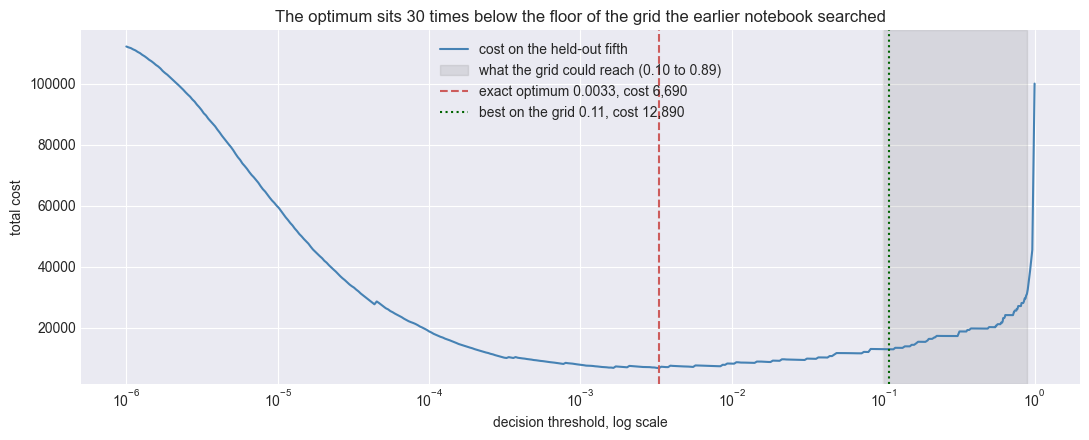

In [16]:
# The full cost curve, on a log axis because the answer lives near zero.
cuts = np.unique(np.concatenate([
    np.logspace(np.log10(max(probe_scores.min(), 1e-6)), 0, 400), GRID]))
curve = np.array([scania_cost(probe_y, (probe_scores >= t).astype(int)) for t in cuts])

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(cuts, curve, color='steelblue', label='cost on the held-out fifth')
ax.axvspan(GRID[0], GRID[-1], color='grey', alpha=0.18,
           label=f'what the grid could reach ({GRID[0]:.2f} to {GRID[-1]:.2f})')
ax.axvline(exact_cut, color='indianred', linestyle='--',
           label=f'exact optimum {exact_cut:.4f}, cost {exact_cost:,}')
ax.axvline(GRID[grid_best], color='darkgreen', linestyle=':',
           label=f'best on the grid {GRID[grid_best]:.2f}, cost {int(grid_costs[grid_best]):,}')
ax.set_xscale('log')
ax.set_xlabel('decision threshold, log scale')
ax.set_ylabel('total cost')
ax.set_title(f'The optimum sits {GRID[0] / exact_cut:.0f} times below the floor of the '
             f'grid the earlier notebook searched')
ax.legend()
plt.tight_layout()
save_figure(fig, 'scania_prep_threshold_search', subfolder=ASSETS)
plt.show()

## 11. Does this agree with the deployed pipeline

`preprocessing_scania.pkl` is what the last completed run left behind, whether
that was `scania_aps.py` or notebook 03 of this pair. Nothing above was imported
from either. If they disagree about the feature list or about whether imputation
is applied, the difference is printed here rather than discovered later by
something downstream that reads the artifact.

In [17]:
shipped_path = PROC_DIR / 'preprocessing_scania.pkl'
if shipped_path.exists():
    shipped = joblib.load(shipped_path)
    checks = [('feature list', features, list(shipped['features'])),
              ('feature count', len(features), len(shipped['features'])),
              ('median imputation applied', False, bool(shipped['median_imputation']))]
    for name, here, there in checks:
        verdict = 'agree' if here == there else 'DIFFER'
        shown = there if not isinstance(there, list) else f'{len(there)} columns'
        print(f'{name:28s} {verdict:6s} (deployed: {shown})')
    print(f"\ndeployed decision threshold: {shipped['threshold']:.6f}")
    print(f"the grid floor {GRID[0]:.2f} is "
          f"{GRID[0] / shipped['threshold']:.0f} times that threshold")
else:
    print('no deployed preprocessing artifact found, nothing to compare against')

feature list                 agree  (deployed: 170 columns)
feature count                agree  (deployed: 170)
median imputation applied    agree  (deployed: False)

deployed decision threshold: 0.002366
the grid floor 0.10 is 42 times that threshold


## 12. Save what notebook 03 needs

Parquet rather than CSV, because the missing values and the float64 dtypes are
the point here and a CSV round trip is where both quietly change.

In [18]:
paths = {
    'train_scania_prepared.parquet': X_train.assign(label=y_train),
    'test_scania_prepared.parquet': X_test.assign(label=y_test),
    'train_scania_textbook.parquet': balanced_X.assign(label=balanced_y)}
for name, frame in paths.items():
    frame.to_parquet(PROC_DIR / name, index=False)

joblib.dump(imputer, PROC_DIR / 'imputer_scania.pkl')
joblib.dump(scaler, PROC_DIR / 'minmax_scania.pkl')

for name in list(paths) + ['imputer_scania.pkl', 'minmax_scania.pkl']:
    size = (PROC_DIR / name).stat().st_size
    print(f'  {name:32s} {size / 1e6:8.1f} MB')

  train_scania_prepared.parquet        28.3 MB
  test_scania_prepared.parquet          8.7 MB
  train_scania_textbook.parquet       104.1 MB
  imputer_scania.pkl                    0.0 MB
  minmax_scania.pkl                     0.0 MB


## 13. Summary

| Decision | The standard recipe | What the measurement says | Where it is settled |
|---|---|---|---|
| Mostly-missing columns | drop above 50 per cent | absence differs between the classes, so dropping and imputing destroy the same signal | kept, all 170 |
| Imputation | median fill | prepared and carried forward as one of four candidates | notebook 03, section 6 |
| Scaling | MinMax to [0, 1] | invisible to a tree, measured on two fits of the same model | not used |
| Resampling | SMOTE to a 50-50 split | prepared in full so its cost can be scored, not argued | notebook 03, section 10 |

The threshold, not the pipeline, is what this dataset rewards: the exact optimum
sits two decades below the floor of the grid the earlier notebook searched.

**Next step:** `03_scania_modeling.ipynb` - the four candidates over three fold
seeds, the test set scored once, the textbook pipeline measured against it, and
the artifacts the risk-event adapter reads.